## Split balance audit: test + 5 CV folds

The two similarity signals are already united (`soamp.splitting`): a graph with an edge if
Morgan/ECFP Tanimoto >= 0.8 **or** QMAP BLOSUM45 identity >= 0.6, clustered with Leiden. Whole
clusters are then assigned to `test` and `fold_0..4`.

What we want from the result, in priority order:

1. **No leakage of the same / near-identical peptide** - all records of a peptide, every duplicate
   (identical SMILES or identical non-`X` sequence) and every near-duplicate (Tanimoto >= 0.95 or
   identity >= 0.90) are in one bucket. These pairs are contracted into one node *before* Leiden runs.
2. **Same proportions in all six buckets** - active/inactive and non-canonical/canonical.
3. Bucket sizes near target (test 20%, each fold 16%).

Why not "no edge at all crosses buckets"? The union graph at the 0.8 / 0.6 thresholds is one giant
connected component (~90% of peptides), so Leiden communities necessarily cut edges, and any split
that kept every edge inside a bucket would be a single bucket. The remaining cross-bucket edges
are *moderate* similarities (0.8-0.95 Tanimoto, 0.6-0.9 identity); they are reported below, not removed.

A *record* is a (peptide, organism) row of `mic_classification_dataset.csv`. The label lives on
the record (a peptide can be active vs *E. coli* and inactive vs *S. aureus*), so proportions are
counted over records, the same units the models are scored on.

**Before** = `data/peptide_split.csv` as committed in git; **after** = the regenerated file
(`python pipeline/splitting/01_build_peptide_split.py`). The fix lives in `soamp.splitting`
(record-weighted objective with `lambda_active`, hard-link contraction).

In [1]:
import io
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from soamp.splitting.build import build_peptide_split, unique_peptides_for_splitting
from soamp.splitting.config import REPO_ROOT, SplittingConfig
from soamp.splitting.graph import compute_fingerprint_edges, compute_qmap_edges, duplicate_pairs
from soamp.utils.config import load_config

pd.set_option("display.width", 160)
CFG = load_config(REPO_ROOT / "config/splitting/base.yaml", SplittingConfig)
DATA = CFG.paths.data_dir

records = pd.read_csv(DATA / CFG.input_files.classification_dataset_filename)
records["is_active"] = (records["label"] == "active").astype(int)
records["has_noncanonical"] = records["has_noncanonical"].astype(str) == "True"

after = pd.read_csv(DATA / CFG.output.filename)
before = pd.read_csv(io.StringIO(subprocess.run(
    ["git", "show", f"HEAD:data/{CFG.output.filename}"],
    cwd=REPO_ROOT, capture_output=True, text=True, check=True).stdout))

def bucket_of(split_df):
    s = split_df.set_index("peptide_id")
    return s["split"].where(s["split"] == "test", "fold_" + s["fold_id"].astype("Int64").astype(str))

TARGET = {"test": CFG.bucketing.test_size,
          **{f"fold_{i}": (1 - CFG.bucketing.test_size) / CFG.bucketing.n_folds
             for i in range(CFG.bucketing.n_folds)}}
print(len(records), "records,", records.peptide_id.nunique(), "peptides")
print("dataset-wide: active", round(records.is_active.mean(), 4),
      "| non-canonical (records)", round(records.has_noncanonical.mean(), 4))

24630 records, 12371 peptides
dataset-wide: active 0.8419 | non-canonical (records) 0.2052


### 1. Audit function

In [2]:
def audit(split_df):
    r = records.copy()
    r["bucket"] = r["peptide_id"].map(bucket_of(split_df))
    assert r["bucket"].notna().all(), "records without a bucket"
    g = r.groupby("bucket")
    t = pd.DataFrame({
        "peptides": g.peptide_id.nunique(),
        "records": g.size(),
        "size_frac": g.size() / len(r),
        "target": pd.Series(TARGET),
        "active_frac": g.is_active.mean(),
        "noncanonical_frac": g.has_noncanonical.mean(),
    })
    t["size_dev"] = t["size_frac"] - t["target"]
    t["active_dev"] = t["active_frac"] - r.is_active.mean()
    t["nc_dev"] = t["noncanonical_frac"] - r.has_noncanonical.mean()
    return t.loc[list(TARGET)]

def verdict(t, tol_rate=0.01, tol_size=0.01):
    checks = {
        f"active within +-{tol_rate}": t.active_dev.abs().max() <= tol_rate,
        f"non-canonical within +-{tol_rate}": t.nc_dev.abs().max() <= tol_rate,
        f"size within +-{tol_size} of target": t.size_dev.abs().max() <= tol_size,
    }
    for k, v in checks.items():
        print("PASS" if v else "FAIL", k)
    return all(checks.values())

### 2. Before (split as committed in git)

In [3]:
t_before = audit(before)
display(t_before.round(4))
print("spread (max-min) active:", round(t_before.active_frac.max() - t_before.active_frac.min(), 4),
      "| non-canonical:", round(t_before.noncanonical_frac.max() - t_before.noncanonical_frac.min(), 4))
ok_before = verdict(t_before)

,peptides,records,size_frac,target,active_frac,noncanonical_frac,size_dev,active_dev,nc_dev
test,2473,4734,0.1922,0.20,0.8131,0.2024,-0.0078,-0.0288,-0.0028
fold_0,1978,3877,0.1574,0.16,0.7805,0.2187,-0.0026,-0.0614,0.0136
fold_1,1979,4042,0.1641,0.16,0.8597,0.2237,0.0041,0.0178,0.0185
fold_2,1978,4046,0.1643,0.16,0.8280,0.1928,0.0043,-0.0139,-0.0124
fold_3,1978,4023,0.1633,0.16,0.8996,0.1864,0.0033,0.0577,-0.0187
fold_4,1985,3908,0.1587,0.16,0.8744,0.2080,-0.0013,0.0325,0.0029


spread (max-min) active: 0.1191 | non-canonical: 0.0372
FAIL active within +-0.01
FAIL non-canonical within +-0.01
PASS size within +-0.01 of target


### 3. After (regenerated `data/peptide_split.csv`)

In [4]:
t_after = audit(after)
display(t_after.round(4))
print("spread (max-min) active:", round(t_after.active_frac.max() - t_after.active_frac.min(), 4),
      "| non-canonical:", round(t_after.noncanonical_frac.max() - t_after.noncanonical_frac.min(), 4))
ok_after = verdict(t_after)
assert ok_after, "regenerated split is not balanced - re-run the pipeline / adjust lambdas"

,peptides,records,size_frac,target,active_frac,noncanonical_frac,size_dev,active_dev,nc_dev
test,2363,4929,0.2001,0.20,0.8430,0.2063,0.0001,0.0011,0.0012
fold_0,1914,3903,0.1585,0.16,0.8427,0.2050,-0.0015,0.0008,-0.0002
fold_1,2015,3995,0.1622,0.16,0.8378,0.2050,0.0022,-0.0041,-0.0002
fold_2,1947,3915,0.1590,0.16,0.8421,0.2051,-0.0010,0.0002,-0.0000
fold_3,2136,3903,0.1585,0.16,0.8427,0.2050,-0.0015,0.0008,-0.0002
fold_4,1996,3985,0.1618,0.16,0.8429,0.2043,0.0018,0.0010,-0.0009


spread (max-min) active: 0.0052 | non-canonical: 0.0021
PASS active within +-0.01
PASS non-canonical within +-0.01
PASS size within +-0.01 of target


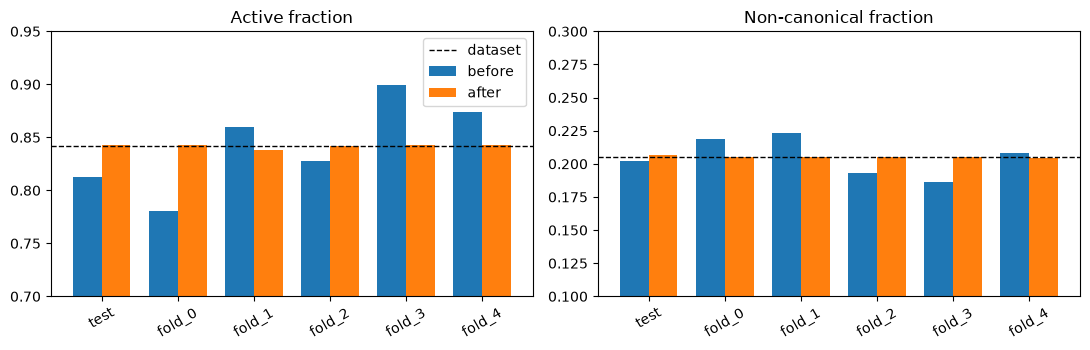

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
x = np.arange(len(TARGET)); w = 0.38
for ax, col, title in [(axes[0], "active_frac", "Active fraction"),
                       (axes[1], "noncanonical_frac", "Non-canonical fraction")]:
    ax.bar(x - w/2, t_before[col], w, label="before")
    ax.bar(x + w/2, t_after[col], w, label="after")
    ax.axhline(records.is_active.mean() if col == "active_frac" else records.has_noncanonical.mean(),
               color="k", ls="--", lw=1, label="dataset")
    ax.set_xticks(x, list(TARGET), rotation=30); ax.set_title(title)
axes[0].set_ylim(0.7, 0.95); axes[1].set_ylim(0.1, 0.3); axes[0].legend()
plt.tight_layout(); plt.show()

### 4. Leakage checks (hard asserts)

* each `peptide_id` is in exactly one bucket - all records of a peptide move together;
* identical `smiles`, and identical non-`X` `sequence`, never straddle buckets (the string `X`
  stands for different non-canonical residues, so such sequences are identified by SMILES);
* no hard-linked pair (duplicate, Tanimoto >= 0.95, identity >= 0.90) crosses buckets;
* the soft (0.8 / 0.6) cross-bucket edge fractions are reported, before vs after.

In [6]:
r = records.copy()
r["bucket"] = r["peptide_id"].map(bucket_of(after))
assert r.groupby("peptide_id").bucket.nunique().max() == 1, "a peptide_id is in several buckets"
assert r.groupby("smiles").bucket.nunique().max() == 1, "a SMILES is in several buckets"
no_x = r[~r["sequence"].str.contains("[Xx]")]
assert no_x.assign(u=no_x["sequence"].str.upper()).groupby("u").bucket.nunique().max() == 1, \
    "an identical non-X sequence is in several buckets"

peps = unique_peptides_for_splitting(records.astype(str).to_dict("records"))
pid = [p["peptide_id"] for p in peps]
seqs, smis = [p["sequence"] for p in peps], [p["smiles"] for p in peps]
fp = compute_fingerprint_edges(pid, smis, CFG.fingerprint_graph.fingerprint_threshold,
                               radius=CFG.fingerprint_graph.radius, n_bits=CFG.fingerprint_graph.n_bits)
qm = compute_qmap_edges(pid, seqs, CFG.qmap_graph.identity_threshold,
                        matrix=CFG.qmap_graph.matrix, gap_open=CFG.qmap_graph.gap_open,
                        gap_extension=CFG.qmap_graph.gap_extension, use_cache=True, show_progress=False)
hard = set(duplicate_pairs(seqs, smis)) \
    | {e for e, s in fp.items() if s >= CFG.hard_links.fingerprint_threshold} \
    | {e for e, s in qm.items() if s >= CFG.hard_links.identity_threshold}

def crossing(split_df, edges):
    b = bucket_of(split_df).reindex(pd.Index(pid).astype(split_df.peptide_id.dtype)).to_numpy()
    assert pd.notna(b).all(), 'peptide_id dtype mismatch'
    return sum(b[i] != b[j] for i, j in edges)

rows = [{"edge set": name, "edges": len(e),
         "cross-bucket before": crossing(before, e), "cross-bucket after": crossing(after, e)}
        for name, e in [("hard links (dups, fp>=.95, id>=.90)", hard),
                        ("fingerprint >= 0.8", fp), ("QMAP identity >= 0.6", qm)]]
leak = pd.DataFrame(rows)
leak["frac before"] = leak["cross-bucket before"] / leak["edges"]
leak["frac after"] = leak["cross-bucket after"] / leak["edges"]
display(leak.round(4))
assert leak.loc[0, "cross-bucket after"] == 0, "hard-linked (duplicate / near-duplicate) pairs leak"
print("no duplicate / near-duplicate leakage")

,edge set,edges,cross-bucket before,cross-bucket after,frac before,frac after
0,"hard links (dups, fp>=.95, id>=.90)",41723,517,0,0.0124,0.0000
1,fingerprint >= 0.8,256689,21604,25626,0.0842,0.0998
2,QMAP identity >= 0.6,185021,16509,13841,0.0892,0.0748


no duplicate / near-duplicate leakage


### 5. Per-organism active fraction (reported, not optimised)

Balancing is on the overall active fraction; per-organism rates follow only as far as the
organism mix is similar between buckets.

In [7]:
r["organism_short"] = r["organism"].str.split().str[:2].str.join(" ")
top = r["organism_short"].value_counts().head(3).index
pivot = (r[r.organism_short.isin(top)].groupby(["organism_short", "bucket"]).is_active.mean()
         .unstack("organism_short").loc[list(TARGET)])
cnt = (r[r.organism_short.isin(top)].groupby(["organism_short", "bucket"]).size()
       .unstack("organism_short").loc[list(TARGET)])
display(pivot.round(3)); display(cnt)

organism_short,Escherichia coli,Pseudomonas aeruginosa,Staphylococcus aureus
bucket,,,
test,0.854,0.816,0.853
fold_0,0.851,0.854,0.825
fold_1,0.850,0.827,0.832
fold_2,0.851,0.800,0.861
fold_3,0.870,0.846,0.804
fold_4,0.877,0.815,0.824


organism_short,Escherichia coli,Pseudomonas aeruginosa,Staphylococcus aureus
bucket,,,
test,1763,1381,1785
fold_0,1467,1056,1380
fold_1,1563,966,1466
fold_2,1542,972,1401
fold_3,1732,887,1284
fold_4,1580,973,1432


### 6. Sensitivity to the balancing weights and bucket seed

Hard-link contraction and Leiden are fixed; only the cluster-to-bucket assignment varies. One
cluster holds ~15% of peptides, so the local search is lumpy and seed-sensitive, which is why the
committed run uses 100k swap iterations and the audit above is the acceptance test. Too large a
weight trades bucket size for composition.

In [8]:
rows = []
for la, ln, seed in [(0, 8, 42), (10, 10, 42), (30, 30, 42), (30, 30, 1), (100, 100, 42)]:
    res = build_peptide_split(peps, bucket_lambda_active=la, bucket_lambda_noncanonical=ln,
                              bucket_seed=seed, bucket_n_iterations=100_000,
                              hard_link_fingerprint_threshold=CFG.hard_links.fingerprint_threshold,
                              hard_link_identity_threshold=CFG.hard_links.identity_threshold,
                              identity_show_progress=False)
    s = pd.DataFrame(res.sidecar["bucket_stats"]).T
    sc = res.sidecar
    rows.append({"lambda_active": la, "lambda_nc": ln, "bucket_seed": seed,
                 "max |size-target|": (s.n_rows / sc["dataset_n_rows"] - s.target_size_fraction).abs().max(),
                 "max |active-dataset|": (s.active_fraction_rows - sc["dataset_active_fraction_rows"]).abs().max(),
                 "max |nc-dataset|": (s.has_noncanonical_fraction_rows - sc["dataset_has_noncanonical_fraction_rows"]).abs().max()})
display(pd.DataFrame(rows).round(4))

,lambda_active,lambda_nc,bucket_seed,max |size-target|,max |active-dataset|,max |nc-dataset|
0,0,8,42,0.0020,0.0951,0.0025
1,10,10,42,0.0059,0.0205,0.0048
2,30,30,42,0.0022,0.0041,0.0012
3,30,30,1,0.0156,0.0004,0.0173
4,100,100,42,0.0286,0.0078,0.0005


### Conclusion

* **Before:** active fraction ranged ~0.78-0.90 across folds; only the peptide-level non-canonical
  rate had been balanced; 67 identical sequence strings (mostly `X`-placeholder ones, which are
  different molecules) and some genuine duplicates sat in different buckets.
* **After:** see tables above - all six buckets within ~1% of the dataset-wide active and
  non-canonical proportions, sizes on target, zero duplicate / near-duplicate pairs across buckets.
* Moderate-similarity cross-bucket edges (the ~10% / ~7% shown in section 4) remain by design.
* Fold/test membership changed, so earlier CV results (wandb) were computed on a different split
  and are not comparable with new runs.